# Auditoría variable por variable — agroforestería, Haití

Antes de confiar cualquier variable dentro del pipeline grande (M1-M6), la traemos **una
por una**, la graficamos, y revisamos sus números. Nada entra al flujo general hasta que la
hayas mirado con tus propios ojos acá.

Cada celda llama a `load_and_align_one_variable()` -- la **misma función exacta** que usa
`assemble_variables()` dentro de M1. No hay dos copias de la lógica: lo que valides acá es
literalmente lo que va a correr después.

## Setup

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path(r"D:\OneDrive - CGIAR\Desktop\codigos_dengue\nbs-ruralscan")
src_path = str(REPO_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nbs_ruralscan.runtime.schema_loader import load_recipe
from nbs_ruralscan.runtime.suitability import load_and_align_one_variable

# Descomentar en tu maquina, una vez autenticado:
# import ee
# ee.Initialize(project="tu-project-id")

SCHEMA_ROOT = REPO_ROOT / "schema"
NBS_ID = "agroforestry"
COUNTRY_ISO3 = "HTI"
RESOLUTION_M = 5000
AOI_BBOX = (-74.5, 18.0, -71.6, 20.1)

recipe = load_recipe(SCHEMA_ROOT, NBS_ID)
print("Recipe cargado:", NBS_ID, "-- variables en T4:", len(recipe.t4))


Recipe cargado: agroforestry -- variables en T4: 19


In [12]:
import ee
import xee 
ee.Authenticate()
ee.Initialize(project="ee-diegoagudelo30-2")

## Función de ayuda -- una celda de auditoría reusable

Para no repetir el mismo bloque de gráfico/estadísticas 8 veces, esta función hace las 3 cosas
que pediste por cada variable: traer, graficar, imprimir números. **No es parte del pipeline
grande** -- es solo para este notebook de chequeo.

In [27]:
import matplotlib.patches as mpatches

def audit_variable(variable_name: str, cmap: str = "viridis", class_labels: dict | None = None):
    row = recipe.t4[recipe.t4["variable"] == variable_name].iloc[0]
    da, audit_row = load_and_align_one_variable(
        variable_name, row, recipe.t1, AOI_BBOX, RESOLUTION_M, country_iso3=COUNTRY_ISO3
    )
    if da is None:
        print(f"{variable_name}: no se pudo cargar ni alinear -- revisa el warning de arriba.")
        return None

    values = da.values
    fill_mask = da.attrs.get("fill_mask")
    pct_filled = 100 * fill_mask.mean() if fill_mask is not None else 0.0
    is_categorical = row["relationship_type"] in ("ranked_classes", "threshold")

    print(f"--- {variable_name} ---")
    print(f"  dataset_id:        {audit_row.dataset_id}")
    print(f"  es sintetico:      {audit_row.is_synthetic}")
    print(f"  resolucion nativa: {audit_row.native_resolution_m} m")
    print(f"  min / max / media: {values.min():.4g} / {values.max():.4g} / {values.mean():.4g}")
    print(f"  shape:             {values.shape}")
    print(f"  % relleno (sin dato real de la fuente): {pct_filled:.1f}%")
    if audit_row.is_synthetic:
        print(f"  fuente recomendada: {audit_row.recommended_source}")

    extent = [float(da.x.min()), float(da.x.max()), float(da.y.min()), float(da.y.max())]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    legend_patches = None

    if is_categorical:
        # Cada categoria ocupa un "casillero" de igual tamano (por rango, no por su valor
        # numerico real) -- evita que codigos con huecos grandes (ej. 60 -> 80) den tramos de
        # color de tamanos desparejos y una leyenda dificil de leer.
        values_present = sorted(set(values[~np.isnan(values)].astype(int).tolist()))
        n = max(len(values_present), 1)
        disc_cmap = plt.get_cmap("tab10", n)
        colors = [disc_cmap(i) for i in range(n)]
        rank_of = {v: i for i, v in enumerate(values_present)}
        ranked = np.full(values.shape, np.nan)
        valid = ~np.isnan(values)
        ranked[valid] = [rank_of[int(v)] for v in values[valid]]

        im = ax1.imshow(
            ranked, cmap=mcolors.ListedColormap(colors), vmin=-0.5, vmax=n - 0.5,
            extent=extent, origin="upper",
        )
        labels = [class_labels.get(v, str(v)) if class_labels else str(v) for v in values_present]
        legend_patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(n)]
    else:
        im = ax1.imshow(values, cmap=cmap, extent=extent, origin="upper")
        plt.colorbar(im, ax=ax1, fraction=0.046)

    ax1.set_title(f"{variable_name}" + (" (SINTETICO)" if audit_row.is_synthetic else " (real)"))
    ax1.set_xlabel("longitud")
    ax1.set_ylabel("latitud")

    if fill_mask is not None:
        coverage = np.where(fill_mask, 1, 0)
        ax2.imshow(coverage, cmap="Reds", vmin=0, vmax=1, extent=extent, origin="upper")
        ax2.set_title(f"cobertura -- {pct_filled:.0f}% relleno (rojo)")
        ax2.set_xlabel("longitud")

    plt.tight_layout()
    if legend_patches:
        n_rows = -(-len(legend_patches) // 4)  # redondeo hacia arriba
        fig.legend(
            handles=legend_patches, loc="upper center", bbox_to_anchor=(0.5, -0.02 - 0.02 * n_rows),
            ncol=min(len(legend_patches), 4), fontsize=8, frameon=False,
        )
        plt.subplots_adjust(bottom=0.1 + 0.08 * n_rows)
    plt.show()

    return da, audit_row

## 1. `slope` -- SRTM DEM (`USGS/SRTMGL1_003`)
La más simple: un solo `ee.Image`, sin colección temporal, sin proyección rara. Es la que
menos debería sorprenderte.

c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\xee\ext.py:615: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(
'slope': reprojecting onto the shared grid left 18/3055 pixel(s) as NaN (source extent didn't exactly cover the target grid) -- filled with the layer's mean (179.6) so downstream weighting stays finite.


--- slope ---
  dataset_id:        srtm_dem_90m
  es sintetico:      False
  resolucion nativa: 30.0 m
  min / max / media: -42 / 2108 / 179.6
  shape:             (47, 65)
  % relleno (sin dato real de la fuente): 0.6%


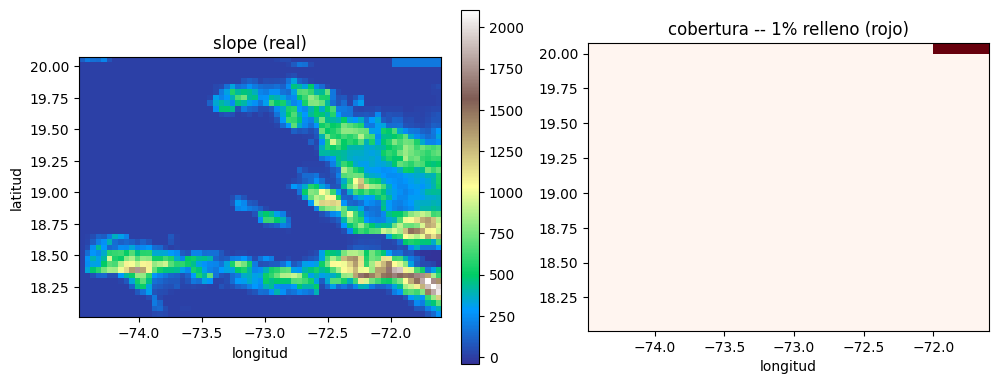

In [28]:
slope_da, slope_audit = audit_variable("slope", cmap="terrain")

## 2. `land_cover` -- ESA WorldCover (`ESA/WorldCover/v200`)
Categórica -- vas a ver un puñado de valores discretos (10, 20, 30...), no un degradé continuo.
Si ves algo suave tipo degradé, algo está mal (compará con el fix de `ranked_classes` que
hicimos).

c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\xee\ext.py:615: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(
'land_cover': reprojecting onto the shared grid left 376/3055 pixel(s) as NaN (source extent didn't exactly cover the target grid) -- filled with the layer's mode (80) so downstream weighting stays finite.


--- land_cover ---
  dataset_id:        esa_worldcover_2021
  es sintetico:      False
  resolucion nativa: 10.0 m
  min / max / media: 10 / 95 / 56.1
  shape:             (47, 65)
  % relleno (sin dato real de la fuente): 12.3%


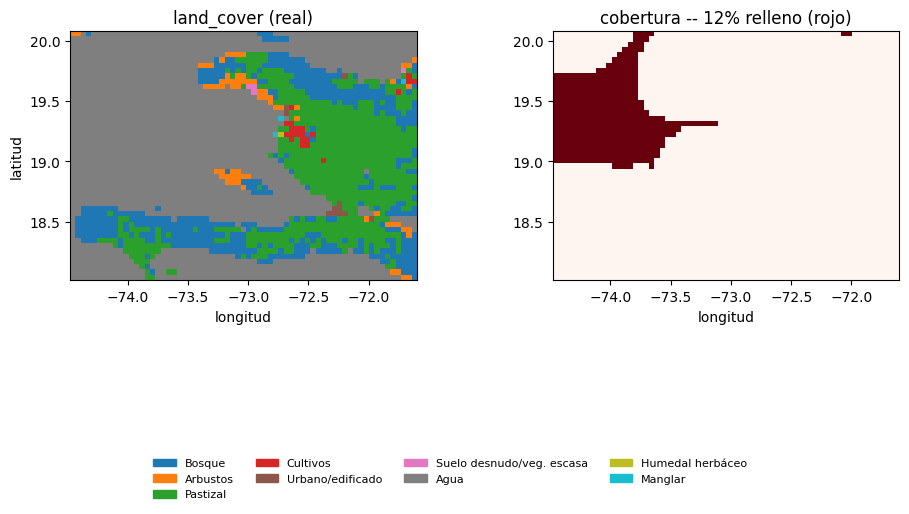

In [29]:
LAND_COVER_LABELS = {
    10: "Bosque", 20: "Arbustos", 30: "Pastizal", 40: "Cultivos",
    50: "Urbano/edificado", 60: "Suelo desnudo/veg. escasa", 70: "Nieve/hielo",
    80: "Agua", 90: "Humedal herbáceo", 95: "Manglar", 100: "Musgo/liquen",
}
land_cover_da, land_cover_audit = audit_variable("land_cover", class_labels=LAND_COVER_LABELS)

## 3. `tree_canopy_cover` -- Hansen Global Forest Change
Porcentaje de cobertura arbórea (0-100). Asset deprecado pero funcional (`_2023_v1_11` ->
`_2025_v1_13` disponible, no migrado todavía).

--- tree_canopy_cover ---
  dataset_id:        hansen_treecover2000
  es sintetico:      False
  resolucion nativa: 30.0 m
  min / max / media: 0 / 94 / 11.31
  shape:             (47, 65)
  % relleno (sin dato real de la fuente): 0.0%


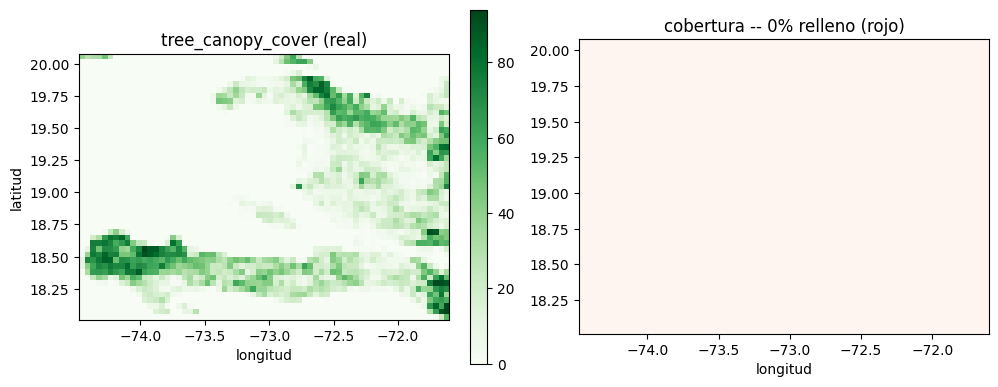

In [30]:
tcc_da, tcc_audit = audit_variable("tree_canopy_cover", cmap="Greens")

## 4. `accessibility_travel_time` -- Oxford/MAP, con la transformación aplicada
**Este es el que más vale la pena mirar con cuidado.** Los valores deberían estar entre 0 y 1
(no en minutos) -- si ves números grandes (decenas, cientos), la transformación `1/(1+x)` no
se está aplicando y hay que revisar por qué.

c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\ee\deprecation.py:214: DeprecationWarning: 

Attention required for Oxford/MAP/accessibility_to_cities_2015_v1_0! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by projects/malariaatlasproject/assets/accessibility/accessibility_to_cities/2015_v1_0

Learn more: https://developers.google.com/earth-engine/datasets/catalog/Oxford_MAP_accessibility_to_cities_2015_v1_0

  warnings.warn(warning, category=DeprecationWarning)
c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\xee\ext.py:615: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(
'accessibility_travel_time': reprojecting onto the shared grid left 1628/3055 pixel(s) as NaN (source extent didn't exactly cover the target grid) -- filled with the layer's mean (65.27) so downstream weight

--- accessibility_travel_time ---
  dataset_id:        nelson_accessibility_2015
  es sintetico:      False
  resolucion nativa: 1000.0 m
  min / max / media: 0.0025 / 1 / 0.03011
  shape:             (47, 65)
  % relleno (sin dato real de la fuente): 53.3%


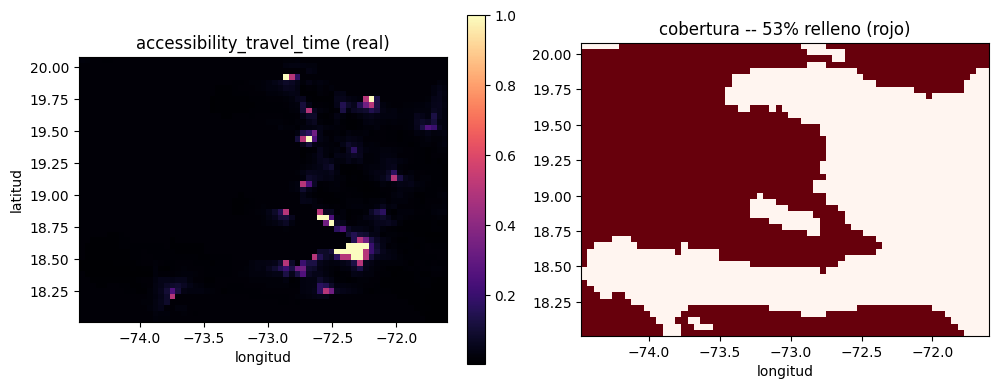


Chequeo directo del rango esperado (0-1): 0.0025 - 1.0


In [17]:
atc_da, atc_audit = audit_variable("accessibility_travel_time", cmap="magma")
print()
print("Chequeo directo del rango esperado (0-1):", atc_da.values.min(), "-", atc_da.values.max())


## 5. `electrification_index` -- VIIRS nighttime lights
Radiancia nocturna -- la mayoría del país va a estar cerca de 0 (rural, sin luz), con picos
en zonas urbanas.

c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\xee\ext.py:615: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


--- electrification_index ---
  dataset_id:        viirs_nighttime_lights
  es sintetico:      False
  resolucion nativa: 500.0 m
  min / max / media: 0.09062 / 10.87 / 0.1691
  shape:             (47, 65)
  % relleno (sin dato real de la fuente): 0.0%


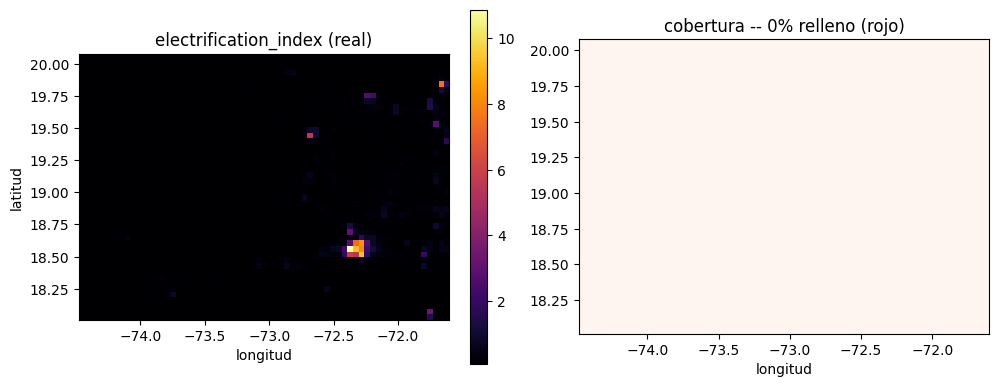

In [31]:
elec_da, elec_audit = audit_variable("electrification_index", cmap="inferno")

## 6. `soil_ph` -- SoilGrids, con el fix de escala /10 aplicado
Debería estar entre ~4 y ~9 (pH real), no entre 40 y 90. Si ves números grandes, el fix de
escala no está activo.

c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\xee\ext.py:615: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(
'soil_ph': reprojecting onto the shared grid left 1622/3055 pixel(s) as NaN (source extent didn't exactly cover the target grid) -- filled with the layer's mean (60.82) so downstream weighting stays finite.


--- soil_ph ---
  dataset_id:        isric_soilgrids250_v2_ph
  es sintetico:      False
  resolucion nativa: 250.0 m
  min / max / media: 5.2 / 7.7 / 6.082
  shape:             (47, 65)
  % relleno (sin dato real de la fuente): 53.1%


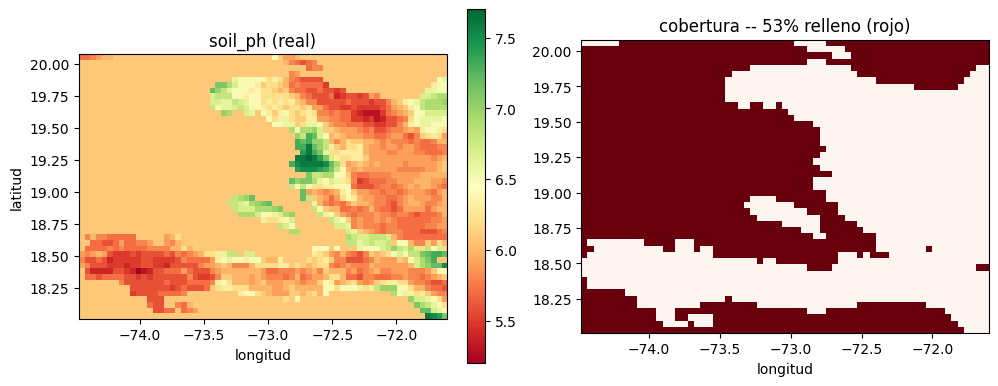


Chequeo directo del rango esperado (4-9): 5.2 - 7.7


In [32]:
ph_da, ph_audit = audit_variable("soil_ph", cmap="RdYlGn")
print()
print("Chequeo directo del rango esperado (4-9):", ph_da.values.min(), "-", ph_da.values.max())


## 7. `soil_organic_carbon` -- SoilGrids, ESCALA SIN CONFIRMAR
**Mirá este con especial atención.** T4 espera un rango angosto (0.5-0.8). Anotá el min/max/
media reales que te salgan acá -- eso es lo que necesitamos para decidir el factor de
conversión correcto (o confirmar con el equipo qué unidad esperaban).

c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\xee\ext.py:615: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(
'soil_organic_carbon': reprojecting onto the shared grid left 1620/3055 pixel(s) as NaN (source extent didn't exactly cover the target grid) -- filled with the layer's mean (490.4) so downstream weighting stays finite.


--- soil_organic_carbon ---
  dataset_id:        isric_soilgrids250_v2_soc
  es sintetico:      False
  resolucion nativa: 250.0 m
  min / max / media: 2.62 / 12.66 / 4.904
  shape:             (47, 65)
  % relleno (sin dato real de la fuente): 53.0%


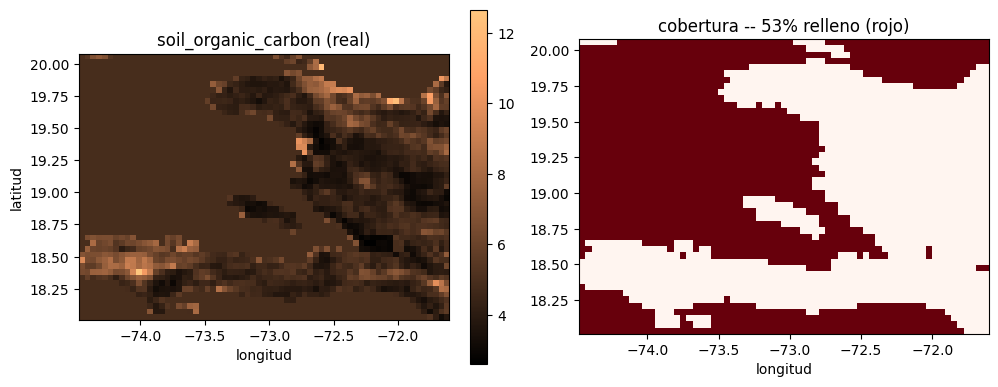

In [33]:
soc_da, soc_audit = audit_variable("soil_organic_carbon", cmap="copper")

## 8. `protected_area_status` -- WDPA (vectorial, esperamos que falle)
Sabemos que esta va a caer a sintético -- WDPA es un `FeatureCollection` de polígonos, y el
loader todavía no sabe rasterizar vectores. La corremos igual para confirmar que falla de forma
prolija (sin romper el notebook) y no de otra manera inesperada.

c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\xee\ext.py:615: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


--- protected_area_status ---
  dataset_id:        protected_areas_wdpa
  es sintetico:      False
  resolucion nativa: nan m
  min / max / media: 0 / 1 / 0.07791
  shape:             (47, 65)
  % relleno (sin dato real de la fuente): 0.0%


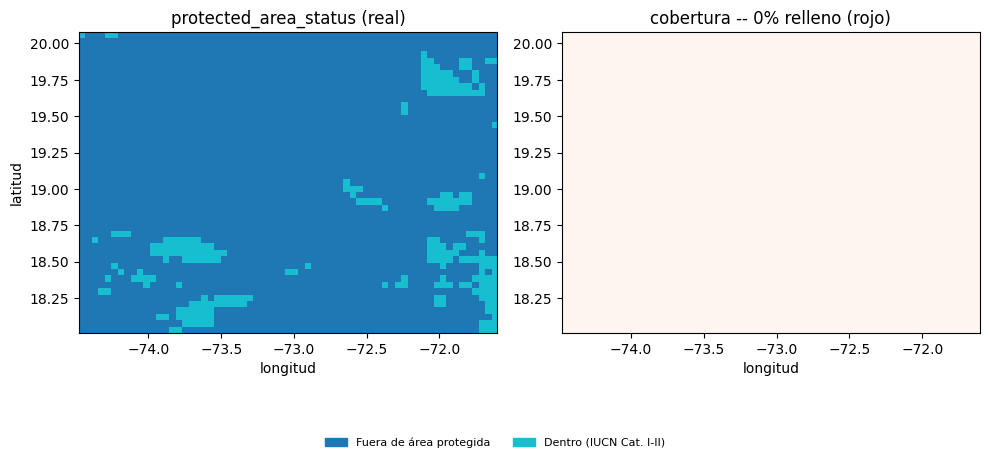

In [35]:
WDPA_LABELS = {0: "Fuera de área protegida", 1: "Dentro (IUCN Cat. I-II)"}
wdpa_da, wdpa_audit = audit_variable("protected_area_status", class_labels=WDPA_LABELS)

## 9. `annual_precipitation` -- WorldClim v2 (descarga local)
Primera prueba real del patrón de raster local (`_load_local_raster`) -- hasta ahora solo
habíamos probado GEE y la tabla de referencia con datos reales. Debería mostrar `(real)`,
no `SINTETICO`, y valores en el rango de cientos a miles de mm/año.

'annual_precipitation': reprojecting onto the shared grid left 1735/3055 pixel(s) as NaN (source extent didn't exactly cover the target grid) -- filled with the layer's mean (1430) so downstream weighting stays finite.


--- annual_precipitation ---
  dataset_id:        worldclim_v2_bioclim_precip
  es sintetico:      False
  resolucion nativa: 1000.0 m
  min / max / media: 543 / 2318 / 1430
  shape:             (47, 65)
  % relleno (sin dato real de la fuente): 56.8%


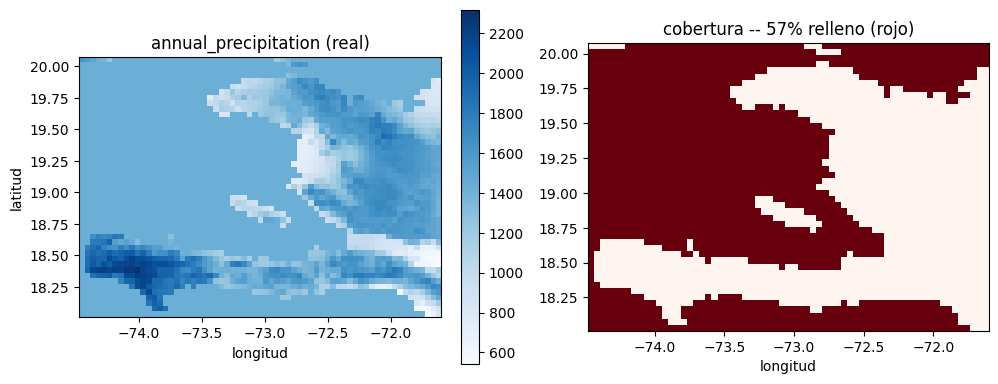

In [36]:
precip_da, precip_audit = audit_variable("annual_precipitation", cmap="Blues")

## 10. `mean_annual_temperature` -- WorldClim v2 (descarga local, mismo zip)

'mean_annual_temperature': reprojecting onto the shared grid left 1735/3055 pixel(s) as NaN (source extent didn't exactly cover the target grid) -- filled with the layer's mean (24.2) so downstream weighting stays finite.


--- mean_annual_temperature ---
  dataset_id:        worldclim_v2_bioclim_temp
  es sintetico:      False
  resolucion nativa: 1000.0 m
  min / max / media: 12.24 / 27.88 / 24.2
  shape:             (47, 65)
  % relleno (sin dato real de la fuente): 56.8%


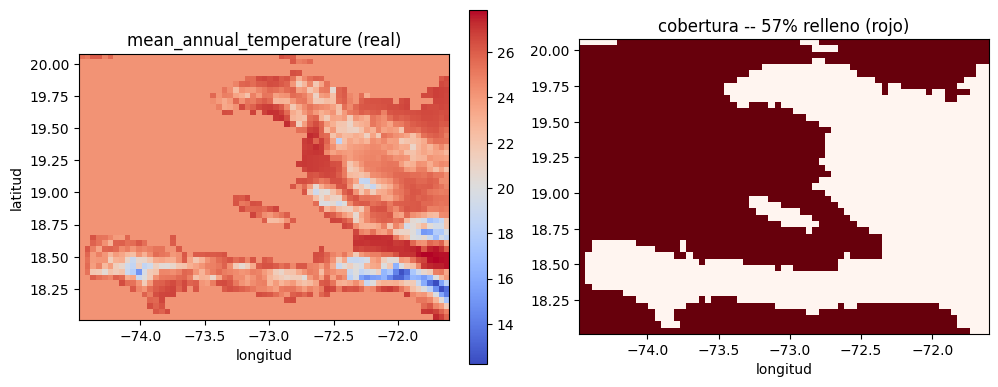

In [37]:
temp_da, temp_audit = audit_variable("mean_annual_temperature", cmap="coolwarm")

## 11. `soil_drainage` -- HWSD v2 (descarga local, formato .bil)

'soil_drainage': reprojecting onto the shared grid left 1714/3055 pixel(s) as NaN (source extent didn't exactly cover the target grid) -- filled with the layer's mode (4) so downstream weighting stays finite.


--- soil_drainage ---
  dataset_id:        hwsd_v2
  es sintetico:      False
  resolucion nativa: 1000.0 m
  min / max / media: 4 / 6 / 4.115
  shape:             (47, 65)
  % relleno (sin dato real de la fuente): 56.1%


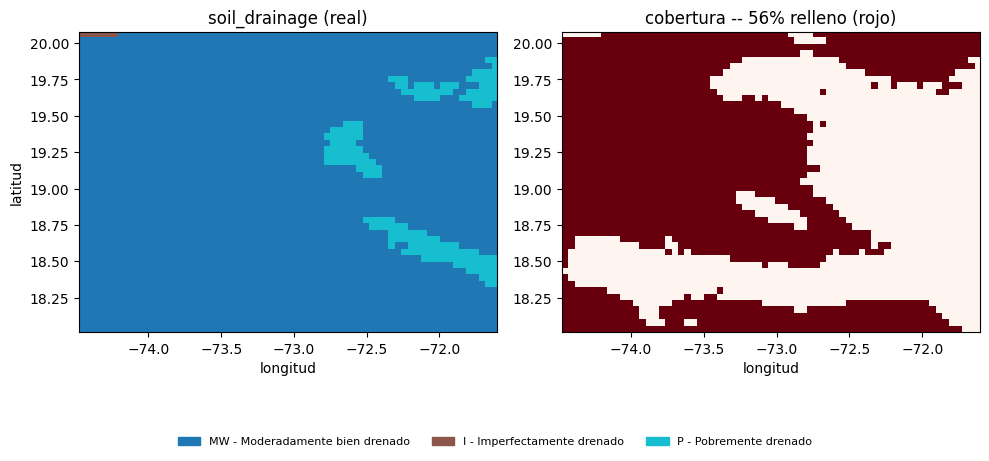

In [38]:
DRAINAGE_LABELS = {
    1: "E - Excesivamente drenado", 2: "SE - Algo excesivamente",
    3: "W - Bien drenado", 4: "MW - Moderadamente bien drenado",
    5: "I - Imperfectamente drenado", 6: "P - Pobremente drenado", 7: "VP - Muy pobremente drenado",
}
drainage_da, drainage_audit = audit_variable("soil_drainage", class_labels=DRAINAGE_LABELS)

## 12. `aridity_index` -- CGIAR-CSI v3.1 (descarga local, con transformación /10000 aplicada)
Debería mostrar valores entre 0 y ~2 (índice real), no en miles (el crudo sin transformar).

--- aridity_index ---
  dataset_id:        global_aridity_index_v3
  es sintetico:      False
  resolucion nativa: 1000.0 m
  min / max / media: 0 / 2.009 / 0.4172
  shape:             (47, 65)
  % relleno (sin dato real de la fuente): 0.0%


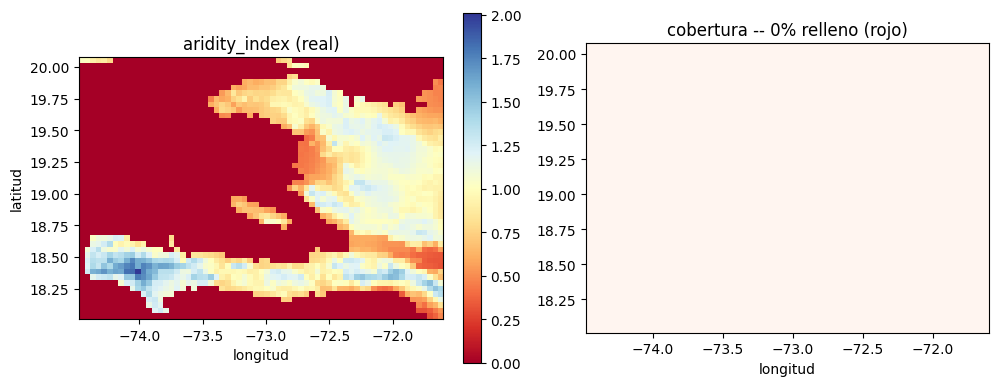


Chequeo directo del rango esperado (0-2): 0.0 - 2.0094


In [39]:
aridity_da, aridity_audit = audit_variable("aridity_index", cmap="RdYlBu")
print()
print("Chequeo directo del rango esperado (0-2):", aridity_da.values.min(), "-", aridity_da.values.max())

## Resumen -- tabla de auditoría consolidada

Juntamos las 8 en una sola tabla para verlas de un vistazo.

In [21]:
results = {
    "slope": slope_audit, "land_cover": land_cover_audit, "tree_canopy_cover": tcc_audit,
    "accessibility_travel_time": atc_audit, "electrification_index": elec_audit,
    "soil_ph": ph_audit, "soil_organic_carbon": soc_audit, "protected_area_status": wdpa_audit,
}
summary = pd.DataFrame([
    {"variable": k, "dataset_id": v.dataset_id, "es_sintetico": v.is_synthetic,
     "resolucion_nativa_m": v.native_resolution_m}
    for k, v in results.items() if v is not None
])
summary


,variable,dataset_id,es_sintetico,resolucion_nativa_m
0,slope,srtm_dem_90m,False,30.0
1,land_cover,esa_worldcover_2021,False,10.0
2,tree_canopy_cover,hansen_treecover2000,False,30.0
3,accessibility_travel_time,nelson_accessibility_2015,False,1000.0
4,electrification_index,viirs_nighttime_lights,False,500.0
5,soil_ph,isric_soilgrids250_v2_ph,False,250.0
6,soil_organic_carbon,isric_soilgrids250_v2_soc,False,250.0
7,protected_area_status,protected_areas_wdpa,False,NaN


## Próximo paso -- consolidar a un solo NetCDF

Una vez que cada variable de arriba te parezca razonable, este es el paso que arma el archivo
consolidado (`xr.Dataset` -> `.to_netcdf()`) para que el pipeline grande deje de volver a
pedirle cada capa a GEE en cada corrida. **Todavía no lo corras** -- primero revisá las 8
variables de arriba con tus propios ojos.

In [ ]:
# import xarray as xr
#
# ds = xr.Dataset({k: v.rename(k) for k, (da, _) in
#                   {"slope": (slope_da, slope_audit), ...}.items()})
# ds.to_netcdf(REPO_ROOT / "pipeline" / "outputs" / "agroforestry_hti_consolidated.nc")
